In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_non_bonded_potential_energy)=
# Get non-bonded potential energy

*Calculating non-bonded (electrostatic and van der Waals) interaction energies between selections.*

The function {func}`molsysmt.molecular_mechanics.get_non_bonded_potential_energy` computes non-bonded interaction energies across molecular interfaces or evaluates residue-by-residue interaction energy matrices.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.molecular_mechanics.get_non_bonded_potential_energy`.
:::


:::{note} Molecular Mechanics Backend Engine
:class: dropdown

Molecular mechanics and force evaluations in MolSysMT are executed using backend simulation engines (currently **OpenMM** by default). MolSysMT intentionally unifies the Pythonic interface and data structures while delegating energy evaluations, parameterizations, and gradient calculations to high-performance, battle-tested molecular simulation engines.
:::


## Basic usage

Let's compute the non-bonded interaction energy across a protein–protein complex interface:


In [2]:
import molsysmt as msm
import pyunitwizard as puw
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['Barnase-Barstar']['barnase_barstar.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We calculate the total non-bonded interaction energy between Barnase and Barstar:


In [4]:
u_nb = msm.molecular_mechanics.get_non_bonded_potential_energy(molsys,
                                                              selection='molecule_name=="BARNASE"',
                                                              selection_2='molecule_name=="BARSTAR"')
print('Total non-bonded interaction energy:', u_nb)


Total non-bonded interaction energy: -3162.292497634964 kilojoule / mole


## Pairwise interaction energy matrix between atom sets

Passing lists of atom selections computes the complete pairwise interaction energy matrix. Here we evaluate the full residue-by-residue interaction matrix between all 110 residues of Barnase and all 89 residues of Barstar:


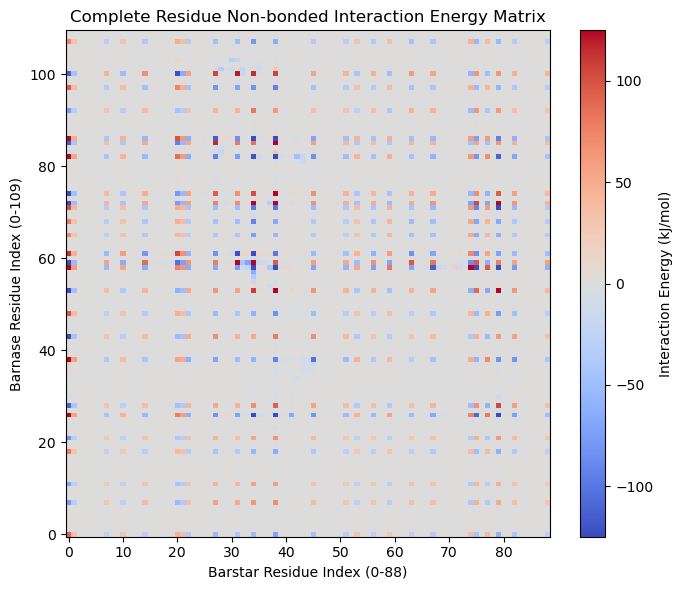

In [5]:
barnase_groups = [msm.select(molsys, selection=f'molecule_name=="BARNASE" and group_index=={ii}') for ii in range(110)]
barstar_groups = [msm.select(molsys, selection=f'molecule_name=="BARSTAR" and group_index=={jj}') for jj in range(110, 199)]

u_matrix = msm.molecular_mechanics.get_non_bonded_potential_energy(molsys, selection=barnase_groups, selection_2=barstar_groups)
u_vals = puw.get_value(u_matrix, to_unit='kJ/mol')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(u_vals, origin='lower', cmap='coolwarm', vmin=-125, vmax=125, aspect='auto')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Interaction Energy (kJ/mol)')
ax.set_title('Complete Residue Non-bonded Interaction Energy Matrix')
ax.set_xlabel('Barstar Residue Index (0-88)')
ax.set_ylabel('Barnase Residue Index (0-109)')
plt.tight_layout()
plt.show()


We can also analyze the net non-bonded interaction contribution per residue for each protein:


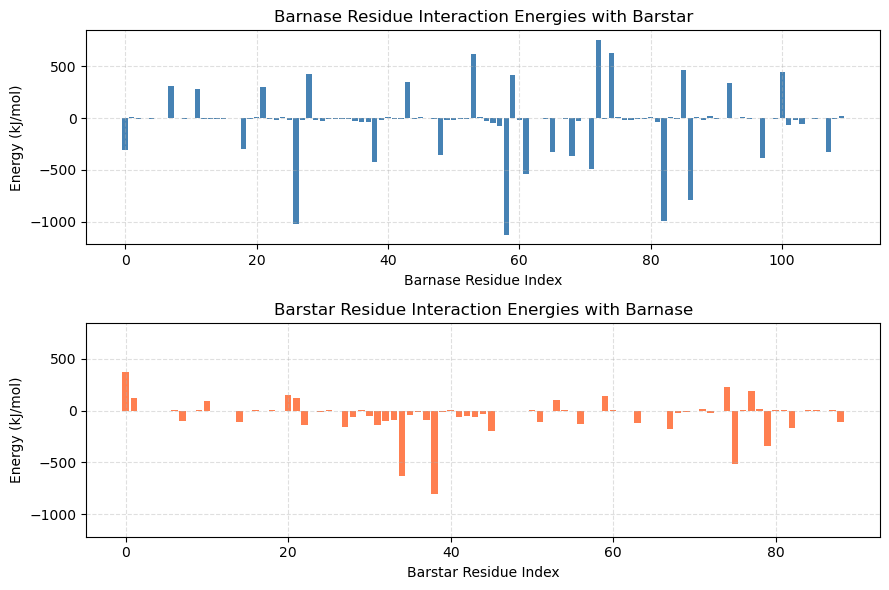

In [6]:
u_barnase_res = puw.get_value(u_matrix.sum(axis=1), to_unit='kJ/mol')
u_barstar_res = puw.get_value(u_matrix.sum(axis=0), to_unit='kJ/mol')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharey=True)
ax1.bar(range(len(u_barnase_res)), u_barnase_res, color='steelblue')
ax1.set_title('Barnase Residue Interaction Energies with Barstar')
ax1.set_xlabel('Barnase Residue Index')
ax1.set_ylabel('Energy (kJ/mol)')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.bar(range(len(u_barstar_res)), u_barstar_res, color='coral')
ax2.set_title('Barstar Residue Interaction Energies with Barnase')
ax2.set_xlabel('Barstar Residue Index')
ax2.set_ylabel('Energy (kJ/mol)')
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Visualizing residue interaction energies in 3D

We project the net non-bonded interaction energy onto each residue in 3D:


In [7]:
# all_res_vals = list(u_barnase_res) + list(u_barstar_res)
# view = msm.view(molsys)
# view.whole.set_color_by_values(all_res_vals, element='group', palette='coolwarm')
# view


```{raw} html
<iframe src="../../../../_static/views/tools_mm_get_non_bonded_potential_energy_1.html" width="100%" height="450px" frameborder="0"></iframe>
```


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Query atom selections with {func}`molsysmt.basic.select`.
- {ref}`Get potential energy <Tutorial_Get_potential_energy>`: Calculate total potential energy with {func}`molsysmt.molecular_mechanics.get_potential_energy`.
:::
